In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('data/phishing_featured.csv')
print("Data Loaded Successfully!")
print("Shape:", df.shape)

Data Loaded Successfully!
Shape: (11055, 36)


In [2]:
X = df.drop('Result', axis=1)
y = df['Result']

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

Train Size: (8844, 35)
Test Size: (2211, 35)


In [3]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=2,
        random_state=42
    ))
])

# Train karo
pipeline.fit(X_train, y_train)

# Accuracy check karo
accuracy = pipeline.score(X_test, y_test)
print("Pipeline Accuracy:", accuracy*100, "%")

Pipeline Accuracy: 95.56761646313885 %


              precision    recall  f1-score   support

          -1       0.97      0.93      0.95       956
           1       0.95      0.98      0.96      1255

    accuracy                           0.96      2211
   macro avg       0.96      0.95      0.95      2211
weighted avg       0.96      0.96      0.96      2211



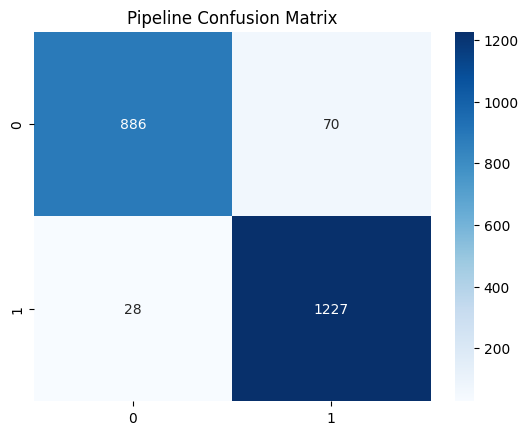

In [4]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = pipeline.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Pipeline Confusion Matrix')
plt.show()

In [5]:
import pickle
import os

# Models folder banao
os.makedirs('models', exist_ok=True)

# Pipeline save karo
with open('models/pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print("Pipeline Saved Successfully!")
print("Location: models/pipeline.pkl")

Pipeline Saved Successfully!
Location: models/pipeline.pkl


In [6]:
with open('models/pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

# Test sample lao
sample = X_test[:5]
predictions = loaded_pipeline.predict(sample)

for i, pred in enumerate(predictions):
    result = "Phishing" if pred == -1 else "Legitimate"
    print(f"Sample {i+1}: {result}")

Sample 1: Phishing
Sample 2: Phishing
Sample 3: Phishing
Sample 4: Legitimate
Sample 5: Legitimate


In [7]:
from sklearn.model_selection import cross_val_score

# Cross validation
scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean()*100, "%")
print("Standard Deviation:", scores.std()*100, "%")

Cross Validation Scores: [0.95160561 0.9547716  0.96517413 0.94482135 0.94843962]
Mean Accuracy: 95.2962460425147 %
Standard Deviation: 0.6942228441193998 %


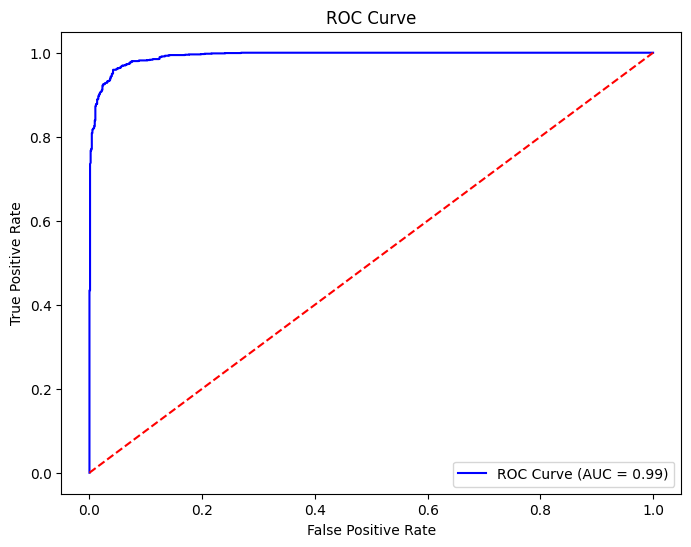

In [8]:
from sklearn.metrics import roc_curve, auc

# ROC Curve
y_pred_proba = pipeline.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Final Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("========== Final Model Summary ==========")
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")
print(f"AUC Score: {roc_auc*100:.2f}%")
print("=========================================")

========== Final Model Summary ==========
Accuracy:  95.57%
Precision: 94.60%
Recall:    97.77%
F1 Score:  96.16%
AUC Score: 99.25%
